In [1]:
import sys
from pathlib import Path

# point this at your repo root (folder that contains "src/")
root = Path.cwd().resolve().parent
chaos83 = root / 'data/bfield/CHAOS-8.3.mat'
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
    
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Validate IGRF Models

In [2]:
from darknessalp.bfield.IGRF13 import igrf13
from pyIGRF import igrf_value

year   = 2015.0
lon    = 0
lmax   = 13

# Avoid poles
eps = 1e-3
lats = np.linspace(-90+eps, 90-eps, 100)

alts = [300, 400, 500]  # km
colors = ['#5D3FD3', '#FF5722', '#00897B']  # iris, orange, teal

plt.figure(figsize=(9,6))

for alt_km, col in zip(alts, colors):
    Bmag_forms = []
    Bmag_ref   = []

    for lat in lats:
        # your IGRF13 implementation
        Bvec = igrf13(year, lat, lon, alt_km, lmax=lmax)
        Bmag_forms.append(np.linalg.norm(Bvec))

        # pyIGRF reference
        D, I, H, X, Y, Z, F = igrf_value(lat, lon, alt_km, year)
        Bmag_ref.append(F * 1e-9)

    Bmag_forms = np.array(Bmag_forms)
    Bmag_ref   = np.array(Bmag_ref)

    # plot both your model and reference
    plt.plot(lats, Bmag_forms*1e6, color=col, lw=2, label=f"Your IGRF13 {alt_km} km")
    plt.plot(lats, Bmag_ref*1e6, ".", color=col, alpha=0.5, label=f"pyIGRF {alt_km} km")

plt.xlabel("Latitude [deg]")
plt.ylabel("Magnetic field strength [µT]")
plt.title(f"IGRF13 comparison at multiple altitudes, lon={lon}°, year={year}")
plt.legend(ncol=2, fontsize=9)
plt.grid(True)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\phial\\AppData\\Roaming\\Python\\Python313\\site-packages\\pyIGRF/src/igrf14coeffs.txt'

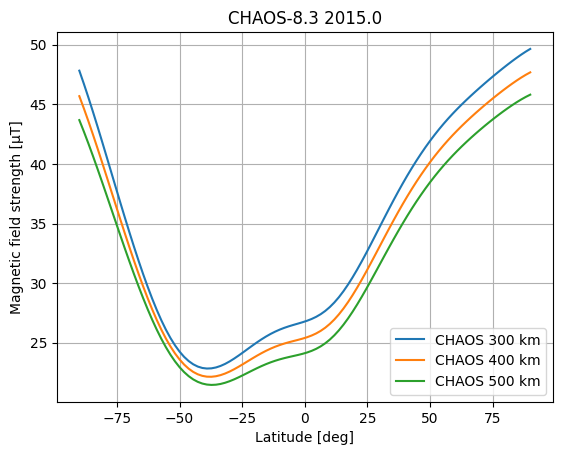

In [ ]:
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt

model = cp.load_CHAOS_matfile(chaos83)

year = 2015.0
lon = 0.0
lats = np.linspace(-90+1e-3, 90-1e-3, 100)
alts = [300, 400, 500]  # km

R_EARTH = 6371.2  # km

for alt_km in alts:
    radius = np.ones_like(lats) * (R_EARTH + alt_km)    # km
    colats = 90.0 - lats                                # deg
    lons   = np.ones_like(lats) * lon
    times  = np.ones_like(lats) * year

    Br, Btheta, Bphi = model.synth_values_tdep(
        times, radius, colats, lons, nmax=65, deriv=0
    )

    Bmag = np.sqrt(Br**2 + Btheta**2 + Bphi**2) * 1e-3  # nT → µT
    plt.plot(lats, Bmag, label=f"CHAOS {alt_km} km")

plt.xlabel("Latitude [deg]")
plt.ylabel("Magnetic field strength [µT]")
plt.title(f"CHAOS-8.3 {year}")
plt.legend()
plt.grid(True)
plt.show()


c:\Users\phial\Documents\Python\darkmatter\.venv\Lib\site-packages\chaosmagpy\chaos.py:422: UserWarning: Supplied nmax = 65 is incompatible with number of coefficients. Using nmax = 20 instead.
  warnings.warn(


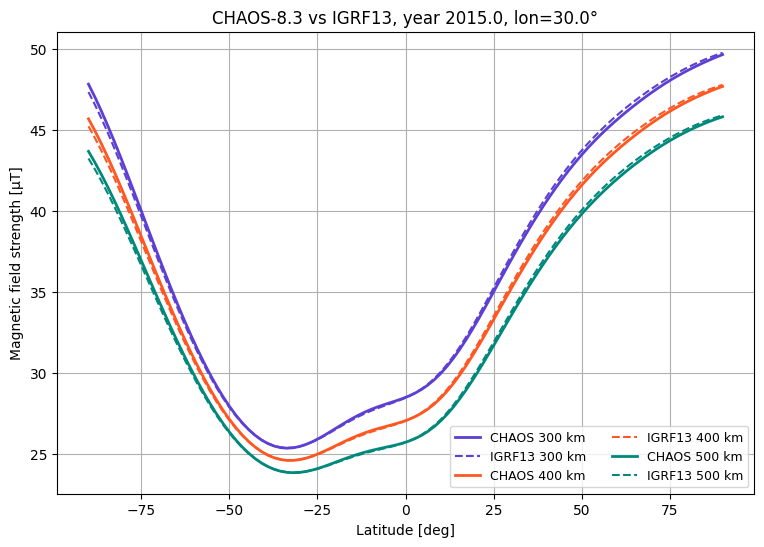

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import chaosmagpy as cp
from darknessalp.bfield.IGRF13 import igrf13

model = cp.load_CHAOS_matfile(chaos83)

year = 2015.0
lon = 30.0
lats = np.linspace(-90+1e-3, 90-1e-3, 100)
alts = [300, 400, 500]  # km
R_EARTH = 6371.2  # km
colors = ['#5D3FD3', '#FF5722', '#00897B']  # iris, orange, teal

plt.figure(figsize=(9,6))

for alt_km, col in zip(alts, colors):
    # --- CHAOS ---
    radius = np.ones_like(lats) * (R_EARTH + alt_km)
    colats = 90.0 - lats
    lons   = np.ones_like(lats) * lon
    times  = np.ones_like(lats) * year

    Br, Btheta, Bphi = model.synth_values_tdep(times, radius, colats, lons, nmax=65, deriv=0)
    Bmag_chaos = np.sqrt(Br**2 + Btheta**2 + Bphi**2) * 1e-3  # nT → µT
    plt.plot(lats, Bmag_chaos, color=col, lw=2, label=f"CHAOS {alt_km} km")

    # --- IGRF13 ---
    Bmag_igrf = []
    for lat in lats:
        Bvec = igrf13(year, lat, lon, alt_km, lmax=13)
        Bmag_igrf.append(np.linalg.norm(Bvec))
    Bmag_igrf = np.array(Bmag_igrf) * 1e6  # T → µT
    plt.plot(lats, Bmag_igrf, "--", color=col, lw=1.5, label=f"IGRF13 {alt_km} km")

plt.xlabel("Latitude [deg]")
plt.ylabel("Magnetic field strength [µT]")
plt.title(f"CHAOS-8.3 vs IGRF13, year {year}, lon={lon}°")
plt.legend(ncol=2, fontsize=9)
plt.grid(True)
plt.show()


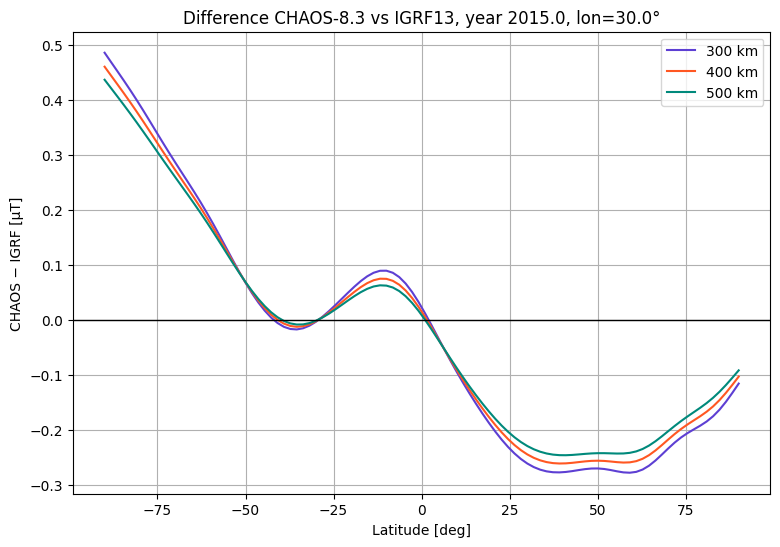

In [ ]:
plt.figure(figsize=(9,6))

for alt_km, col in zip(alts, colors):
    # CHAOS
    radius = np.ones_like(lats) * (R_EARTH + alt_km)
    colats = 90.0 - lats
    lons   = np.ones_like(lats) * lon
    times  = np.ones_like(lats) * year

    Br, Btheta, Bphi = model.synth_values_tdep(times, radius, colats, lons, nmax=65, deriv=0)
    Bmag_chaos = np.sqrt(Br**2 + Btheta**2 + Bphi**2) * 1e-3  # µT

    # IGRF
    Bmag_igrf = []
    for lat in lats:
        Bvec = igrf13(year, lat, lon, alt_km, lmax=13)
        Bmag_igrf.append(np.linalg.norm(Bvec))
    Bmag_igrf = np.array(Bmag_igrf) * 1e6  # µT

    # difference
    diff = Bmag_chaos - Bmag_igrf
    plt.plot(lats, diff, color=col, label=f"{alt_km} km")

plt.axhline(0, color='k', lw=1)
plt.xlabel("Latitude [deg]")
plt.ylabel("CHAOS − IGRF [µT]")
plt.title(f"Difference CHAOS-8.3 vs IGRF13, year {year}, lon={lon}°")
plt.legend()
plt.grid(True)
plt.show()


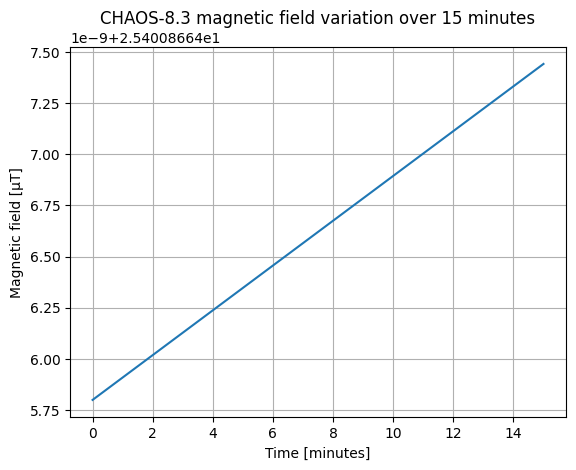

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import chaosmagpy as cp

model = cp.load_CHAOS_matfile(chaos83)

# Location: equator, lon=0°, alt=400 km
lat = 0.0
lon = 0.0
alt_km = 400
R_EARTH = 6371.2

# time range: 15 minutes around 2015-01-01T00:00
# CHAOS expects decimal years
t0 = 2015.0                    # 2015 Jan 1, 00:00
minutes = np.linspace(0, 15, 901)   # 0→15 min in 1s steps
# convert minutes to fraction of year
dyear = minutes / (60*24*365.25)

times = t0 + dyear

# fixed spatial coordinates
radius = np.ones_like(times) * (R_EARTH + alt_km)
colat  = np.ones_like(times) * (90 - lat)
lons   = np.ones_like(times) * lon

Br, Btheta, Bphi = model.synth_values_tdep(times, radius, colat, lons, nmax=65, deriv=0)
Bmag = np.sqrt(Br**2 + Btheta**2 + Bphi**2) * 1e-3  # µT

plt.plot(minutes, Bmag)
plt.xlabel("Time [minutes]")
plt.ylabel("Magnetic field [µT]")
plt.title("CHAOS-8.3 magnetic field variation over 15 minutes")
plt.grid(True)
plt.show()


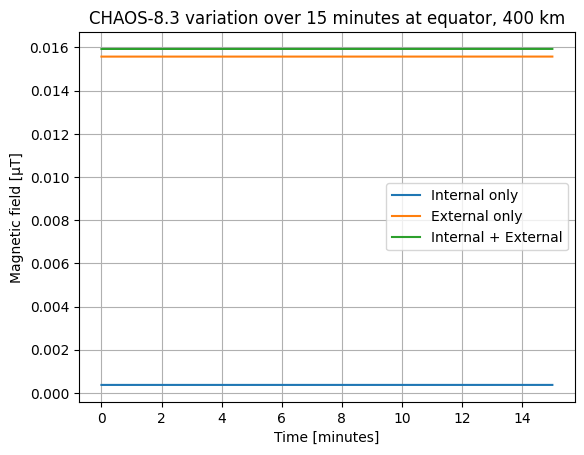

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import chaosmagpy as cp

model = cp.load_CHAOS_matfile(chaos83)

R_EARTH = 6371.2

# Location: lat=0°, lon=0°, alt=400 km
lat, lon, alt_km = 0.0, 0.0, 400
radius = R_EARTH + alt_km
colat  = 90 - lat

# Time vector: 15 minutes, 1-min cadence
t0 = 2015.0
minutes = np.linspace(0, 15, 16)
times = t0 + minutes / (60*24*365.25)   # fraction of year

# External + internal field in SM coordinates
Br_int, Bt_int, Bp_int = model.synth_values_sm(times, radius, colat, lon, source='internal')
Br_ext, Bt_ext, Bp_ext = model.synth_values_sm(times, radius, colat, lon, source='external')

Bmag_internal = np.sqrt(Br_int**2 + Bt_int**2 + Bp_int**2) * 1e-3
Bmag_external = np.sqrt(Br_ext**2 + Bt_ext**2 + Bp_ext**2) * 1e-3
Bmag_total    = np.sqrt((Br_int+Br_ext)**2 + (Bt_int+Bt_ext)**2 + (Bp_int+Bp_ext)**2) * 1e-3

plt.plot(minutes, Bmag_internal, label="Internal only")
plt.plot(minutes, Bmag_external, label="External only")
plt.plot(minutes, Bmag_total, label="Internal + External")
plt.xlabel("Time [minutes]")
plt.ylabel("Magnetic field [µT]")
plt.title("CHAOS-8.3 variation over 15 minutes at equator, 400 km")
plt.legend()
plt.grid(True)
plt.show()



## Step 2: Suzaku Archival Obs
Suzaku’s X-ray Imaging Spectrometer (XIS) was actually a set of four CCD cameras:
XIS0 — front-illuminated (FI)
XIS1 — back-illuminated (BI)
XIS2 — FI (failed in 2006, not used later)
XIS3 — FI

In [ ]:
repo_root = Path().resolve().parent  # from notebooks/, go up one
data_dir = repo_root / "data"
if str(data_dir) not in sys.path:
    sys.path.insert(0, str(data_dir))

from darknessalp.yamamoto.suzaku_archive import OBSIDS, load_orbit, load_attitude, load_event

# Path to your CALMASK file
calmask_path = r"..\data\suzaku\ae_xi0_calmask_20060731.fits"

# Load data
mask = fits.getdata(calmask_path)

obsid = OBSIDS["LockmanHole"][0]  # e.g., "101002010"
orbit = load_orbit(obsid)
att = load_attitude(obsid)
evt = load_event(obsid, xis=0)

print("Orbit columns:", orbit.keys())
print("Attitude columns:", att.keys())
print("Event shape:", evt["X"].shape, evt["Y"].shape)


Orbit columns: dict_keys(['EPOCH', 'A', 'E', 'I', 'AN', 'AP', 'MA', 'A.DOT', 'E.DOT', 'I.DOT', 'AN.DOT', 'AP.DOT', 'N', 'T', 'TIME', 'YYYYMMDD', 'HHMMSS'])
Attitude columns: dict_keys(['TIME', 'YYYYMMDD', 'HHMMSS', 'JD', 'EULER', 'DELTA', 'STATUS', 'ACP_RESI', 'IRU_DRIFT', 'IRU_DELTA', 'KALMAN_GAIN', 'STTA_RESI', 'STTB_RESI', 'NSAS_RESI', 'EULER_OLD', 'XOFFSET', 'YOFFSET', 'T_86', 'T_DY', 'FLAG_ATTCOR'])
Event shape: (16453,) (16453,)


In [3]:
from pathlib import Path
import numpy as np
from astropy.io import fits
from astropy.time import Time


repo_root = Path().resolve().parent
data_dir = repo_root / "data"
if str(data_dir) not in sys.path:
    sys.path.insert(0, str(data_dir))

from darknessalp.yamamoto.suzaku_archive import OBSIDS, load_orbit, load_attitude, load_event

# --- Load Suzaku data ---
obsid = OBSIDS["LockmanHole"][0]
orbit = load_orbit(obsid)      # columns: TIME, X, Y, Z, etc.
att   = load_attitude(obsid)   # pointing RA, DEC, roll
evt   = load_event(obsid, xis=0)


In [4]:
print("\n=== ORBIT OBJECT ===")
print(type(orbit))
try:
    print("Keys:", orbit.keys())
except Exception:
    print("Attributes:", dir(orbit))

# if it’s a FITS HDUList or dict of arrays, inspect one or two fields:
for key in list(orbit.keys())[:5]:
    arr = orbit[key]
    print(f"{key}: type={type(arr)}, shape={np.shape(arr)}")
    if isinstance(arr, np.ndarray):
        print("  Sample:", arr[:5])

# --- Attitude ---
att_path = data_dir / "suzaku" / "101002010" / "ae101002010.att"
from astropy.io import fits
with fits.open(att_path) as hdul:
    hdul.info()
    print(hdul[1].columns)
    print(hdul[1].data[:3])

# --- Event file (inside xis0 folder) ---
evt_path = data_dir / "suzaku" / "101002010" / "xis0"
for f in evt_path.glob("*.evt"):
    print("Found:", f.name)



=== ORBIT OBJECT ===
<class 'dict'>
Keys: dict_keys(['EPOCH', 'A', 'E', 'I', 'AN', 'AP', 'MA', 'A.DOT', 'E.DOT', 'I.DOT', 'AN.DOT', 'AP.DOT', 'N', 'T', 'TIME', 'YYYYMMDD', 'HHMMSS'])
EPOCH: type=<class 'numpy.ndarray'>, shape=(6, 6)
  Sample: [[2006    5   11    0    0    0]
 [2006    5   14    0    0    0]
 [2006    5   17   23    0    0]
 [2006    5   20   21    0    0]
 [2006    5   24   19    0    0]]
A: type=<class 'numpy.ndarray'>, shape=(6,)
  Sample: [6943.14549984 6943.01677572 6942.93589638 6942.79785301 6942.70005731]
E: type=<class 'numpy.ndarray'>, shape=(6,)
  Sample: [5.185900e-05 4.507210e-04 8.222200e-04 1.020251e-03 1.195461e-03]
I: type=<class 'numpy.ndarray'>, shape=(6,)
  Sample: [31.40469574 31.40493291 31.40269465 31.40365709 31.40365963]
AN: type=<class 'numpy.ndarray'>, shape=(6,)
  Sample: [243.32016328 224.33993063 199.29801804 180.84274533 156.06121275]
Filename: C:\Users\phial\Documents\Python\darkmatter\data\suzaku\101002010\ae101002010.att
No.    Name   

Filename: C:\Users\phial\Documents\Python\darkmatter\data\suzaku\101002010\xis0\ae101002010xi0_0_3x3n000a_cl.evt
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     180   ()      
  1  EVENTS        1 BinTableHDU    432   16453R x 27C   [1I, 1I, 1I, 1I, 1I, 1I, 1I, 1I, 1I, 1I, 1I, 1J, 9I, 1I, 1I, 1I, 1I, 1I, 1I, 1I, 1J, 1D, 1D, 1I, 1J, 1D, 1D]   
  2  GTI           1 BinTableHDU     56   26R x 2C   [1D, 1D]   
Columns: ['SEGMENT', 'RAWX', 'RAWY', 'ACTX', 'ACTY', 'DETX', 'DETY', 'FOCX', 'FOCY', 'X']
Rows: 16453


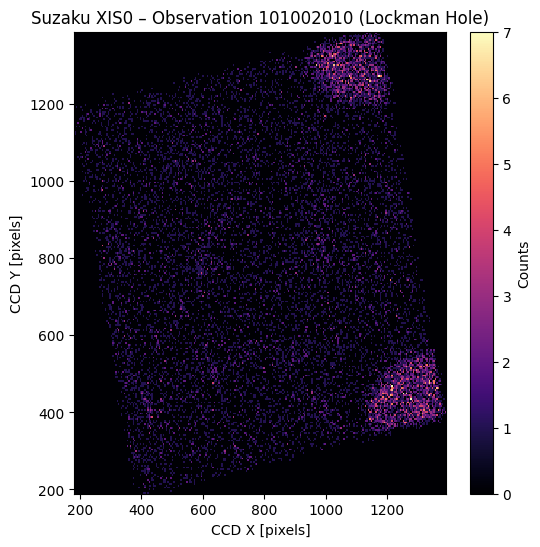

In [5]:
from astropy.io import fits
import matplotlib.pyplot as plt

evt_path = data_dir / "suzaku" / "101002010" / "xis0" / "ae101002010xi0_0_3x3n000a_cl.evt"

with fits.open(evt_path) as hdul:
    hdul.info()
    data = hdul[1].data
    print("Columns:", data.names[:10])
    print("Rows:", len(data))

# Basic 2D image
x, y = data["X"], data["Y"]
plt.figure(figsize=(6,6))
plt.hist2d(x, y, bins=256, cmap="magma")
plt.xlabel("CCD X [pixels]")
plt.ylabel("CCD Y [pixels]")
plt.title("Suzaku XIS0 – Observation 101002010 (Lockman Hole)")
plt.colorbar(label="Counts")
plt.show()


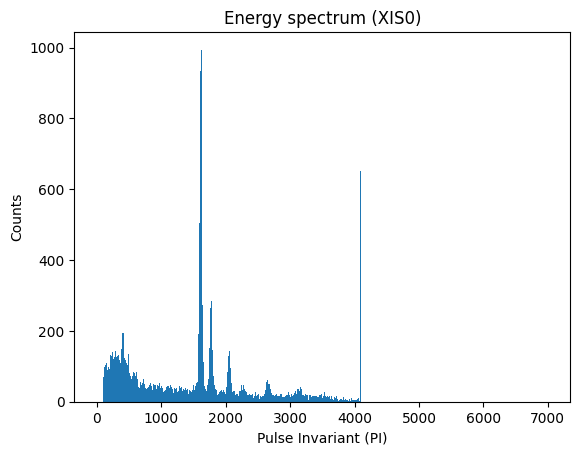

In [ ]:
plt.hist(data['PI'], bins=500, range=(0, 7000))
plt.xlabel("Pulse Invariant (PI)")
plt.ylabel("Counts")
plt.title("Energy spectrum (XIS0)")
plt.show()


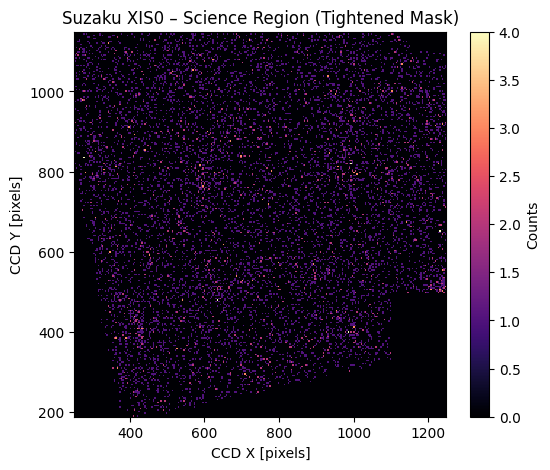

In [ ]:
# Extended masking (for XIS0 geometry)
# More surgical masking
mask = np.ones_like(data['X'], dtype=bool)
mask &= ~((data['X'] > 1150) & (data['Y'] > 1100))   # top-right corner
mask &= ~((data['X'] > 1100) & (data['Y'] < 500))    # bottom-right corner
mask &= (data['X'] > 250) & (data['X'] < 1250) & (data['Y'] > 150) & (data['Y'] < 1150)
sci = data[mask]


plt.figure(figsize=(6,5))
plt.hist2d(sci['X'], sci['Y'], bins=256, cmap='magma')
plt.xlabel("CCD X [pixels]")
plt.ylabel("CCD Y [pixels]")
plt.title("Suzaku XIS0 – Science Region (Tightened Mask)")
plt.colorbar(label="Counts")
plt.show()



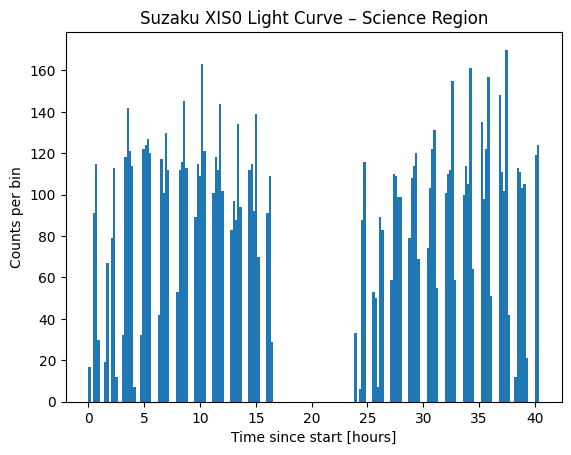

In [ ]:
import matplotlib.pyplot as plt

times = sci['TIME'] - sci['TIME'][0]
plt.hist(times / 3600, bins=200)
plt.xlabel("Time since start [hours]")
plt.ylabel("Counts per bin")
plt.title("Suzaku XIS0 Light Curve – Science Region")
plt.show()



In [6]:
from pathlib import Path
from astropy.io import fits
import numpy as np

ehk_path = Path("../data/suzaku/101002010/ae101002010.ehk")

with fits.open(ehk_path) as hdul:
    hdul.info()
    data = hdul[1].data
    cols = data.names
    print("Columns:", cols[:15])  # show first few column names
    print("Number of rows:", len(data))
    print("\nSample rows:")
    for k in ['TIME', 'COR2', 'ELV', 'SAA', 'T_SAA', 'DYE_ELV']:
        if k in cols:
            print(k, "→", data[k][:5])


Filename: C:\Users\phial\Documents\Python\darkmatter\data\suzaku\101002010\ae101002010.ehk
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      18   ()      
  1  ASTE_EHK      1 BinTableHDU    252   177791R x 34C   [1D, 1J, 1J, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1B, 1E, 1E, 1B, 1E, 1E, 1E, 1E, 1E, 1E]   
Columns: ['TIME', 'YYYYMMDD', 'HHMMSS', 'EULER1', 'EULER2', 'EULER3', 'FOC_RA', 'FOC_DEC', 'FOC_ROLL', 'DLT_RA', 'DLT_DEC', 'DLT_ROLL', 'ANG_DIST', 'SAT_ALT', 'SAT_LON']
Number of rows: 177791

Sample rows:
TIME → [2.01202930e+08 2.01202931e+08 2.01202932e+08 2.01202933e+08
 2.01202934e+08]
COR2 → [13.37088  13.366399 13.3619   13.357384 13.352849]
ELV → [-0.37608954 -0.3366175  -0.29746172 -0.258137   -0.2186249 ]
SAA → [2 2 2 2 2]
T_SAA → [0. 0. 0. 0. 0.]
DYE_ELV → [-0.37608954 -0.3366175  -0.29746172 -0.258137   -0.2186249 ]


In [7]:
import numpy as np
good_mask = (
    (data['SAA'] == 0) &
    (data['ELV'] > 5) &
    (data['DYE_ELV'] > 20) &
    (data['COR2'] > 8)
)
good_times = data['TIME'][good_mask]
print(f"Fraction of good time: {np.mean(good_mask):.2f}")


Fraction of good time: 0.38


Good events fraction: 0.66
Selected 10,870 photons out of 16,453


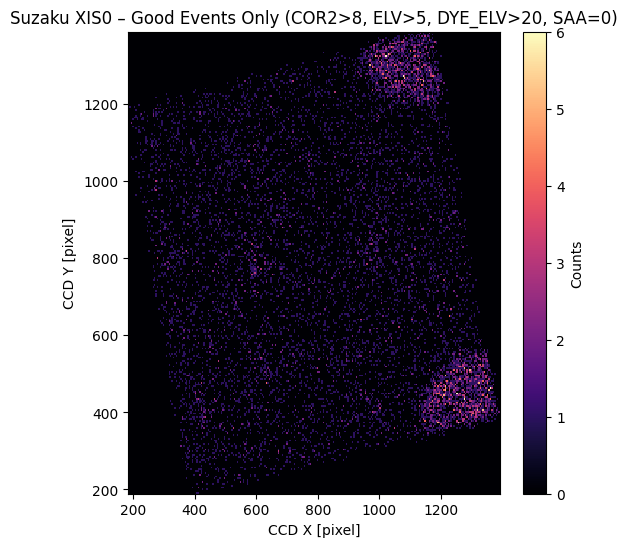

In [9]:
import numpy as np
from astropy.io import fits

# --- Load event data ---
evt_path = Path("../data/suzaku/101002010/xis0/ae101002010xi0_0_3x3n000a_cl.evt")
with fits.open(evt_path) as hdul:
    events = hdul[1].data

# --- Interpolate housekeeping quantities onto event times ---
evt_time = events['TIME']
ehk_time = data['TIME']

# Interpolations (NaN where out of range)
cor2 = np.interp(evt_time, ehk_time, data['COR2'])
elv  = np.interp(evt_time, ehk_time, data['ELV'])
dye  = np.interp(evt_time, ehk_time, data['DYE_ELV'])
saa  = np.interp(evt_time, ehk_time, data['SAA'])  # will be fractional, we’ll round

# --- Apply same filters ---
good_evt_mask = (
    (saa < 0.5) &    # equivalent to SAA == 0
    (elv > 5) &
    (dye > 20) &
    (cor2 > 8)
)
print(f"Good events fraction: {np.mean(good_evt_mask):.2f}")

good_events = events[good_evt_mask]
print(f"Selected {len(good_events):,} photons out of {len(events):,}")

import matplotlib.pyplot as plt
import numpy as np

x = good_events["X"]
y = good_events["Y"]

plt.figure(figsize=(6,6))
plt.hist2d(x, y, bins=256, cmap="magma")
plt.xlabel("CCD X [pixel]")
plt.ylabel("CCD Y [pixel]")
plt.title("Suzaku XIS0 – Good Events Only (COR2>8, ELV>5, DYE_ELV>20, SAA=0)")
plt.colorbar(label="Counts")
plt.show()


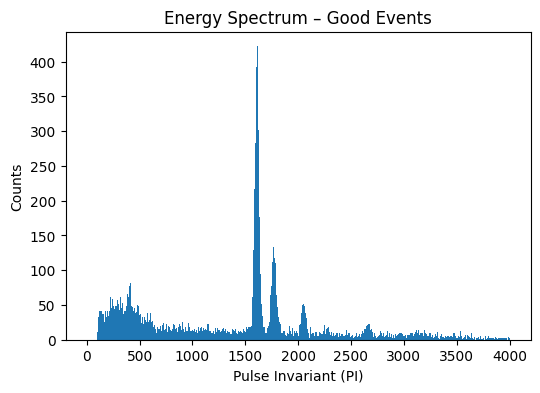

In [10]:
plt.figure(figsize=(6,4))
plt.hist(good_events["PI"], bins=500, range=(0,4000))
plt.xlabel("Pulse Invariant (PI)")
plt.ylabel("Counts")
plt.title("Energy Spectrum – Good Events")
plt.show()


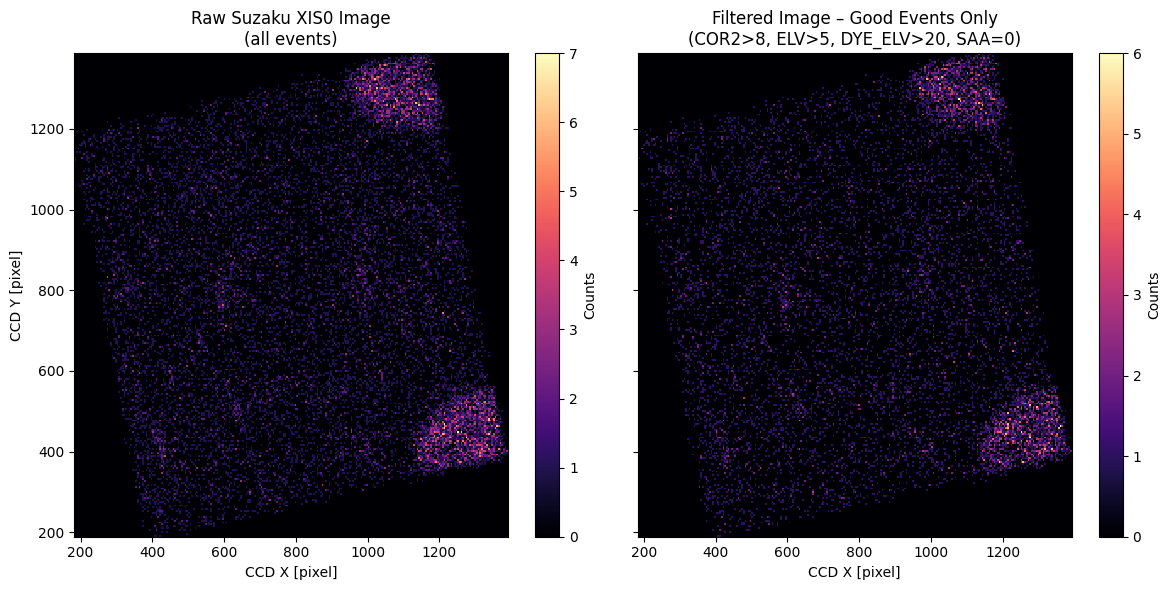

In [11]:
import matplotlib.pyplot as plt
import numpy as np

x_raw, y_raw = events["X"], events["Y"]
x_good, y_good = good_events["X"], good_events["Y"]

fig, axs = plt.subplots(1, 2, figsize=(12,6), sharex=True, sharey=True)

# --- Left: Raw image ---
im0 = axs[0].hist2d(x_raw, y_raw, bins=256, cmap="magma")
axs[0].set_title("Raw Suzaku XIS0 Image\n(all events)")
axs[0].set_xlabel("CCD X [pixel]")
axs[0].set_ylabel("CCD Y [pixel]")
fig.colorbar(im0[3], ax=axs[0], label="Counts")

# --- Right: Good image ---
im1 = axs[1].hist2d(x_good, y_good, bins=256, cmap="magma")
axs[1].set_title("Filtered Image – Good Events Only\n(COR2>8, ELV>5, DYE_ELV>20, SAA=0)")
axs[1].set_xlabel("CCD X [pixel]")
fig.colorbar(im1[3], ax=axs[1], label="Counts")

plt.tight_layout()
plt.show()


Shape: (1024, 1024)   Unique values: [0. 1.]


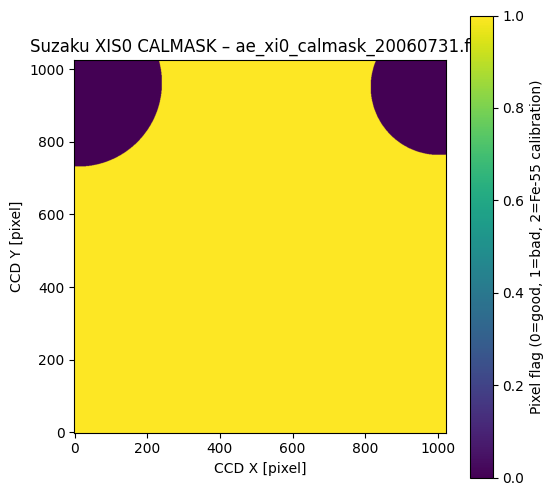

In [12]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

# Path to your CALMASK file
calmask_path = r"..\data\suzaku\ae_xi0_calmask_20060731.fits"

# Load data
mask = fits.getdata(calmask_path)
print("Shape:", mask.shape, "  Unique values:", np.unique(mask))

# Plot
plt.figure(figsize=(6,6))
im = plt.imshow(mask, origin='lower', cmap='viridis')
plt.title("Suzaku XIS0 CALMASK – ae_xi0_calmask_20060731.fits")
plt.xlabel("CCD X [pixel]")
plt.ylabel("CCD Y [pixel]")
cbar = plt.colorbar(im)
cbar.set_label("Pixel flag (0=good, 1=bad, 2=Fe-55 calibration)")
plt.show()

